️Step 1: Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier


Step 2: Load the dataset

In [2]:
df = pd.read_csv("C:\\Users\\Chetana\\Downloads\\WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Step 3: Basic Checks

In [5]:
df.shape


(1470, 35)

In [6]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


STEP-4: Check missing values

In [7]:
df.isnull().sum()


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [8]:
df["Attrition"].value_counts()


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Step 4: Encoding Categorical Variables

In [9]:
df = pd.get_dummies(df, drop_first=True)
df.head()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,1,2,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,1,4,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,1,5,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,7,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


Step 5: Feature–Target Split


In [10]:
X = df.drop("Attrition_Yes", axis=1)
y = df["Attrition_Yes"]


Step 6: Train–Test Split (Stratified)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


Step 7: Feature Scaling

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Parametric Model

Step 8: Logistic Regression

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [14]:
y_pred_lr = lr.predict(X_test_scaled)
accuracy_score(y_test, y_pred_lr)


0.8798185941043084

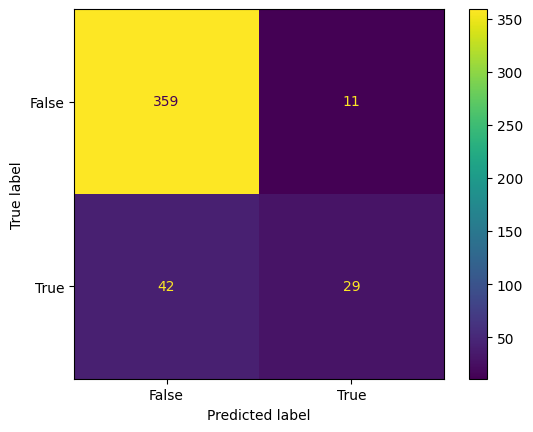

In [15]:
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.show()


Non-Parametric Models

Step 9: AdaBoost Classifier

In [16]:
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)
ada.fit(X_train_scaled, y_train)


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [17]:
y_pred_ada = ada.predict(X_test_scaled)
accuracy_score(y_test, y_pred_ada)


0.8503401360544217

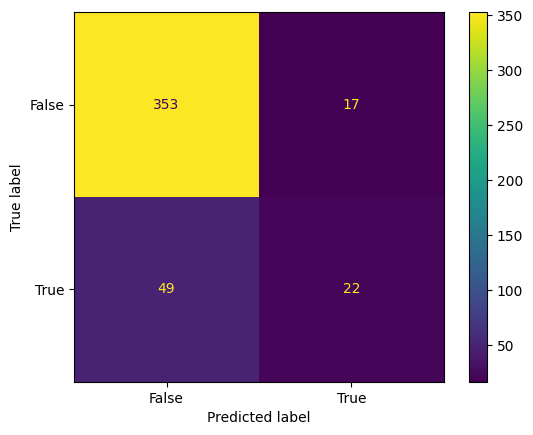

In [18]:
ConfusionMatrixDisplay.from_estimator(ada, X_test_scaled, y_test)
plt.show()


Step 10: Support Vector Machine

In [19]:
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
y_pred_svm = svm.predict(X_test_scaled)
accuracy_score(y_test, y_pred_svm)


0.8616780045351474

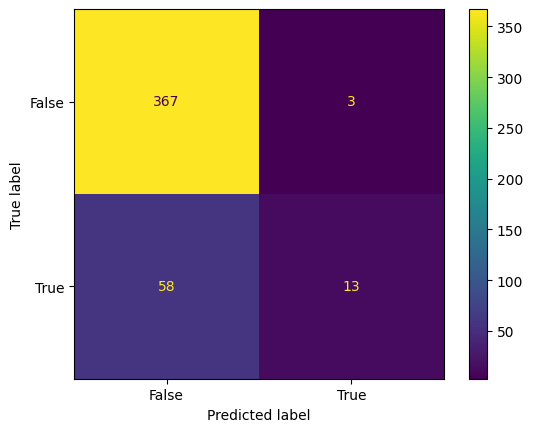

In [21]:
ConfusionMatrixDisplay.from_estimator(svm, X_test_scaled, y_test)
plt.show()


Step 11: Import evaluation metrics

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score


Step 12: Create a comparison function

In [29]:
def evaluate_model(name, y_test, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }
results = []

results.append(evaluate_model("Logistic Regression", y_test, y_pred_lr))
results.append(evaluate_model("AdaBoost", y_test, y_pred_ada))
results.append(evaluate_model("SVM", y_test, y_pred_svm))
results_df = pd.DataFrame(results)
results_df



,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.879819,0.725000,0.408451,0.522523
1,AdaBoost,0.850340,0.564103,0.309859,0.400000
2,SVM,0.861678,0.812500,0.183099,0.298851


Step 13: Accuracy comparison table

In [33]:

accuracy_df = results_df[["Model", "Accuracy"]].sort_values(
    by="Accuracy", ascending=False
)

accuracy_df


,Model,Accuracy
0,Logistic Regression,0.879819
2,SVM,0.861678
1,AdaBoost,0.850340


Step 14: Confusion Matrix of the BEST model

In [35]:
best_model_name = results_df.sort_values(
    by="F1 Score", ascending=False
).iloc[0]["Model"]

best_model_name


'Logistic Regression'

In [36]:
model_dict = {
    "Logistic Regression": lr,
    "AdaBoost": ada,
    "SVM": svm,
}

best_model = model_dict[best_model_name]


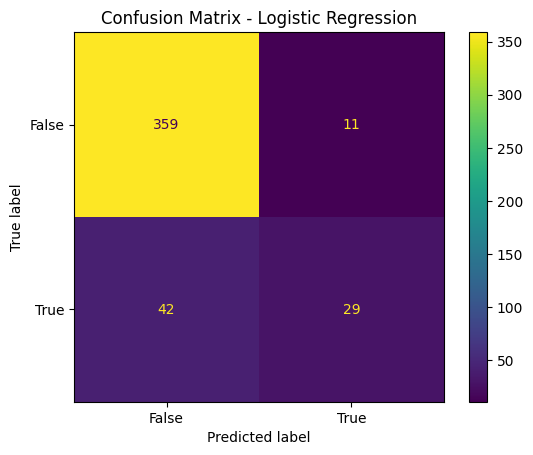

In [37]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_scaled,
    y_test
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


Model Interpretation

Step 15: Beta Coefficients & Odds Ratios

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

Extract β (Beta) Coefficients 

In [40]:
beta_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Beta (β)": lr.coef_[0]
})

beta_df["|Beta|"] = beta_df["Beta (β)"].abs()

beta_df = beta_df.sort_values("|Beta|", ascending=False)

beta_df.head(10)


,Feature,Beta (β),|Beta|
46,OverTime_Yes,0.869160,0.869160
26,BusinessTravel_Travel_Frequently,0.690114,0.690114
37,JobRole_Laboratory Technician,0.674006,0.674006
42,JobRole_Sales Executive,0.619538,0.619538
24,YearsSinceLastPromotion,0.616700,0.616700
43,JobRole_Sales Representative,0.561369,0.561369
13,NumCompaniesWorked,0.492015,0.492015
19,TotalWorkingYears,-0.461553,0.461553
6,EnvironmentSatisfaction,-0.451398,0.451398
23,YearsInCurrentRole,-0.437912,0.437912


 Interpret Direction of Effect

In [41]:
beta_df["Effect_on_Attrition"] = np.where(
    beta_df["Beta (β)"] > 0,
    "Increases attrition risk",
    "Decreases attrition risk"
)

beta_df.head(10)


,Feature,Beta (β),|Beta|,Effect_on_Attrition
46,OverTime_Yes,0.869160,0.869160,Increases attrition risk
26,BusinessTravel_Travel_Frequently,0.690114,0.690114,Increases attrition risk
37,JobRole_Laboratory Technician,0.674006,0.674006,Increases attrition risk
42,JobRole_Sales Executive,0.619538,0.619538,Increases attrition risk
24,YearsSinceLastPromotion,0.616700,0.616700,Increases attrition risk
43,JobRole_Sales Representative,0.561369,0.561369,Increases attrition risk
13,NumCompaniesWorked,0.492015,0.492015,Increases attrition risk
19,TotalWorkingYears,-0.461553,0.461553,Decreases attrition risk
6,EnvironmentSatisfaction,-0.451398,0.451398,Decreases attrition risk
23,YearsInCurrentRole,-0.437912,0.437912,Decreases attrition risk


 Odds Ratio

In [42]:
beta_df["Odds_Ratio"] = np.exp(beta_df["Beta (β)"])

beta_df.head(10)  


,Feature,Beta (β),|Beta|,Effect_on_Attrition,Odds_Ratio
46,OverTime_Yes,0.869160,0.869160,Increases attrition risk,2.384908
26,BusinessTravel_Travel_Frequently,0.690114,0.690114,Increases attrition risk,1.993943
37,JobRole_Laboratory Technician,0.674006,0.674006,Increases attrition risk,1.962081
42,JobRole_Sales Executive,0.619538,0.619538,Increases attrition risk,1.858070
24,YearsSinceLastPromotion,0.616700,0.616700,Increases attrition risk,1.852803
43,JobRole_Sales Representative,0.561369,0.561369,Increases attrition risk,1.753070
13,NumCompaniesWorked,0.492015,0.492015,Increases attrition risk,1.635609
19,TotalWorkingYears,-0.461553,0.461553,Decreases attrition risk,0.630304
6,EnvironmentSatisfaction,-0.451398,0.451398,Decreases attrition risk,0.636737
23,YearsInCurrentRole,-0.437912,0.437912,Decreases attrition risk,0.645382
